# Tytuł projektu:
Ryby w wodzie

# Członkowie zespołu:
Mateusz Adamczyk
Mikołaj Batkiewicz
Aleksander Kaczyński

# 1. Import bibliotek i wczytanie danych

In [51]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import cv2
import random
import numpy as np

data_dir = Path("data") 
sets = ['train', 'valid', 'test']

fishes_data = {}

# Wczytanie danych
for s in sets:
    json_path = data_dir / s / "_annotations.coco.json"
    with open(json_path) as f:
        fishes_data[s] = json.load(f)

# Wyciągnięcie mapowania ID klasy na jej nazwę (korzystamy z folderu train jako bazy)
fish_categories = {ryba['id']: ryba['name'] for ryba in fishes_data['train']['categories']}

print(f"Pomyślnie wczytano dane z folderów: {sets}")

Pomyślnie wczytano dane z folderów: ['train', 'valid', 'test']


# Podstawowe statystyki i braki w danych - Liczba obrazów, Liczba unikalnych klas, Braki w anotacjach

In [52]:
# Zdefiniowanie klas, które nas interesują
target_classes = ['fish', 'jellyfish']

# Znalezienie ID tych klas w słowniku (zabezpieczenie wielkości liter)
target_cat_ids = {}
for cat_id, cat_name in fish_categories.items():
    if cat_name.lower() in [tc.lower() for tc in target_classes]:
        target_cat_ids[cat_name.lower()] = cat_id

print(f"Znalezione ID dla interesujących nas klas: {target_cat_ids}")

# --- 1. OGÓLNE STATYSTYKI ZBIORU ---
basic_stats = []
total_images = 0
total_missing_annotations = 0

for s in sets:
    images = fishes_data[s]['images']
    annotations = fishes_data[s]['annotations']
    categories = fishes_data[s]['categories']
    
    img_ids_with_fish = set([ann['image_id'] for ann in annotations])
    all_img_ids = set([img['id'] for img in images])
    missing_anns = len(all_img_ids - img_ids_with_fish)
    
    total_images += len(images)
    total_missing_annotations += missing_anns
    
    basic_stats.append({
        'Zbiór': s.upper(),
        'Liczba obrazów': len(images),
        'Liczba unikalnych klas': len(categories),
        'Liczba wszystkich bboxów': len(annotations),
        'Obrazy bez anotacji': missing_anns
    })

print("--- PODSTAWOWE STATYSTYKI ZBIORU (OGÓLNE) ---")
display(pd.DataFrame(basic_stats))

# --- 2. STATYSTYKI DLA KONKRETNYCH KLAS ---
for target_class in target_classes:
    if target_class not in target_cat_ids:
        print(f"\nUWAGA: Nie znaleziono klasy '{target_class}' w pliku JSON!")
        continue
        
    class_id = target_cat_ids[target_class]
    class_stats = []
    
    for s in sets:
        images = fishes_data[s]['images']
        annotations = fishes_data[s]['annotations']
        
        # Filtrujemy bbox'y tylko dla tej klasy
        class_bboxes = [ann for ann in annotations if ann['category_id'] == class_id]
        
        # Zliczamy unikalne obrazy, na których występuje ta klasa
        img_ids_with_class = set([ann['image_id'] for ann in class_bboxes])
        
        class_stats.append({
            'Zbiór': s.upper(),
            'Liczba obrazów z klasą': len(img_ids_with_class),
            'Liczba bboxów (wystąpień)': len(class_bboxes)
        })
        
    print(f"\n--- STATYSTYKI DLA KLASY: {target_class.upper()} ---")
    display(pd.DataFrame(class_stats))

Znalezione ID dla interesujących nas klas: {'fish': 15, 'jellyfish': 18}
--- PODSTAWOWE STATYSTYKI ZBIORU (OGÓLNE) ---


,Zbiór,Liczba obrazów,Liczba unikalnych klas,Liczba wszystkich bboxów,Obrazy bez anotacji
0,TRAIN,857,28,4246,0
1,VALID,267,28,1253,0
2,TEST,194,28,916,0



--- STATYSTYKI DLA KLASY: FISH ---


,Zbiór,Liczba obrazów z klasą,Liczba bboxów (wystąpień)
0,TRAIN,240,1961
1,VALID,63,459
2,TEST,30,249



--- STATYSTYKI DLA KLASY: JELLYFISH ---


,Zbiór,Liczba obrazów z klasą,Liczba bboxów (wystąpień)
0,TRAIN,32,385
1,VALID,9,155
2,TEST,11,154


# Analiza rozmiarów obrazów - Rozmiary obrazów (min, max, średni) (wykres punktowy)

--- STATYSTYKI ROZMIARÓW OBRAZÓW (Cały zbiór) ---


,Szerokość,Wysokość
min,416.000000,416.000000
max,1024.000000,1024.000000
mean,606.421851,677.754173



--- STATYSTYKI ROZMIARÓW OBRAZÓW (Zbiór: TRAIN) ---


,Szerokość,Wysokość
min,416.000000,416.00000
max,1024.000000,1024.00000
mean,625.362894,696.38273



--- STATYSTYKI ROZMIARÓW OBRAZÓW (Zbiór: VALID) ---


,Szerokość,Wysokość
min,416.000000,416.000000
max,1024.000000,1024.000000
mean,598.292135,675.235955



--- STATYSTYKI ROZMIARÓW OBRAZÓW (Zbiór: TEST) ---


,Szerokość,Wysokość
min,416.000000,416.000000
max,1024.000000,1024.000000
mean,533.938144,598.927835


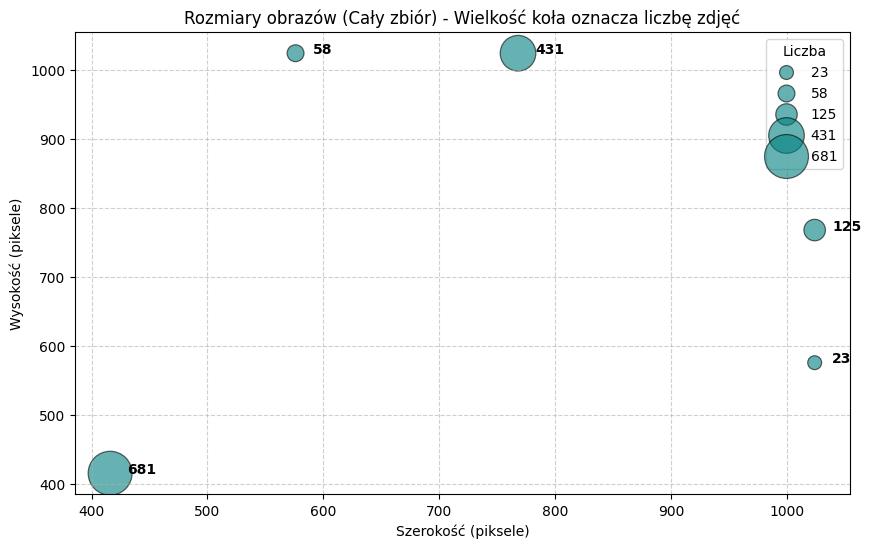

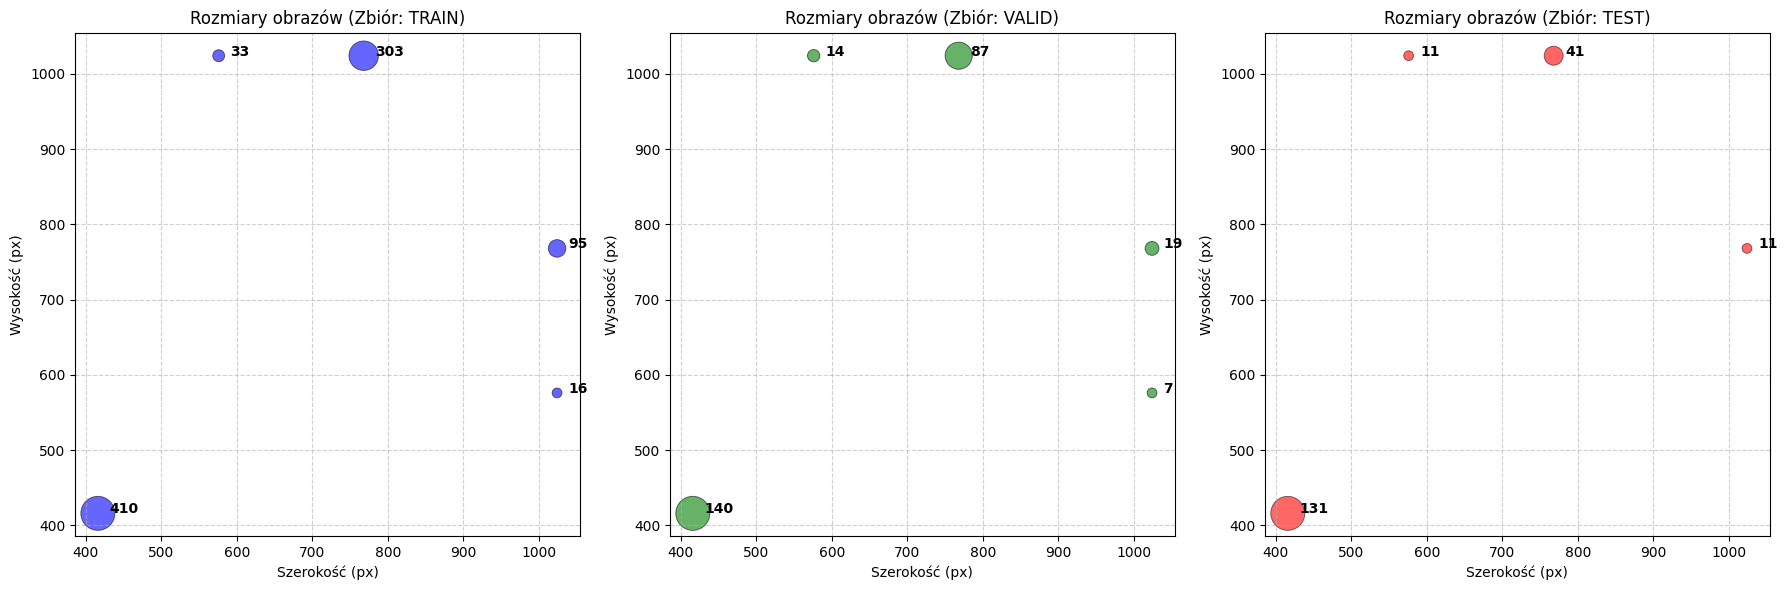


--- ANALIZA ROZMIARÓW OBRAZÓW TYLKO DLA WYBRANYCH KLAS ---


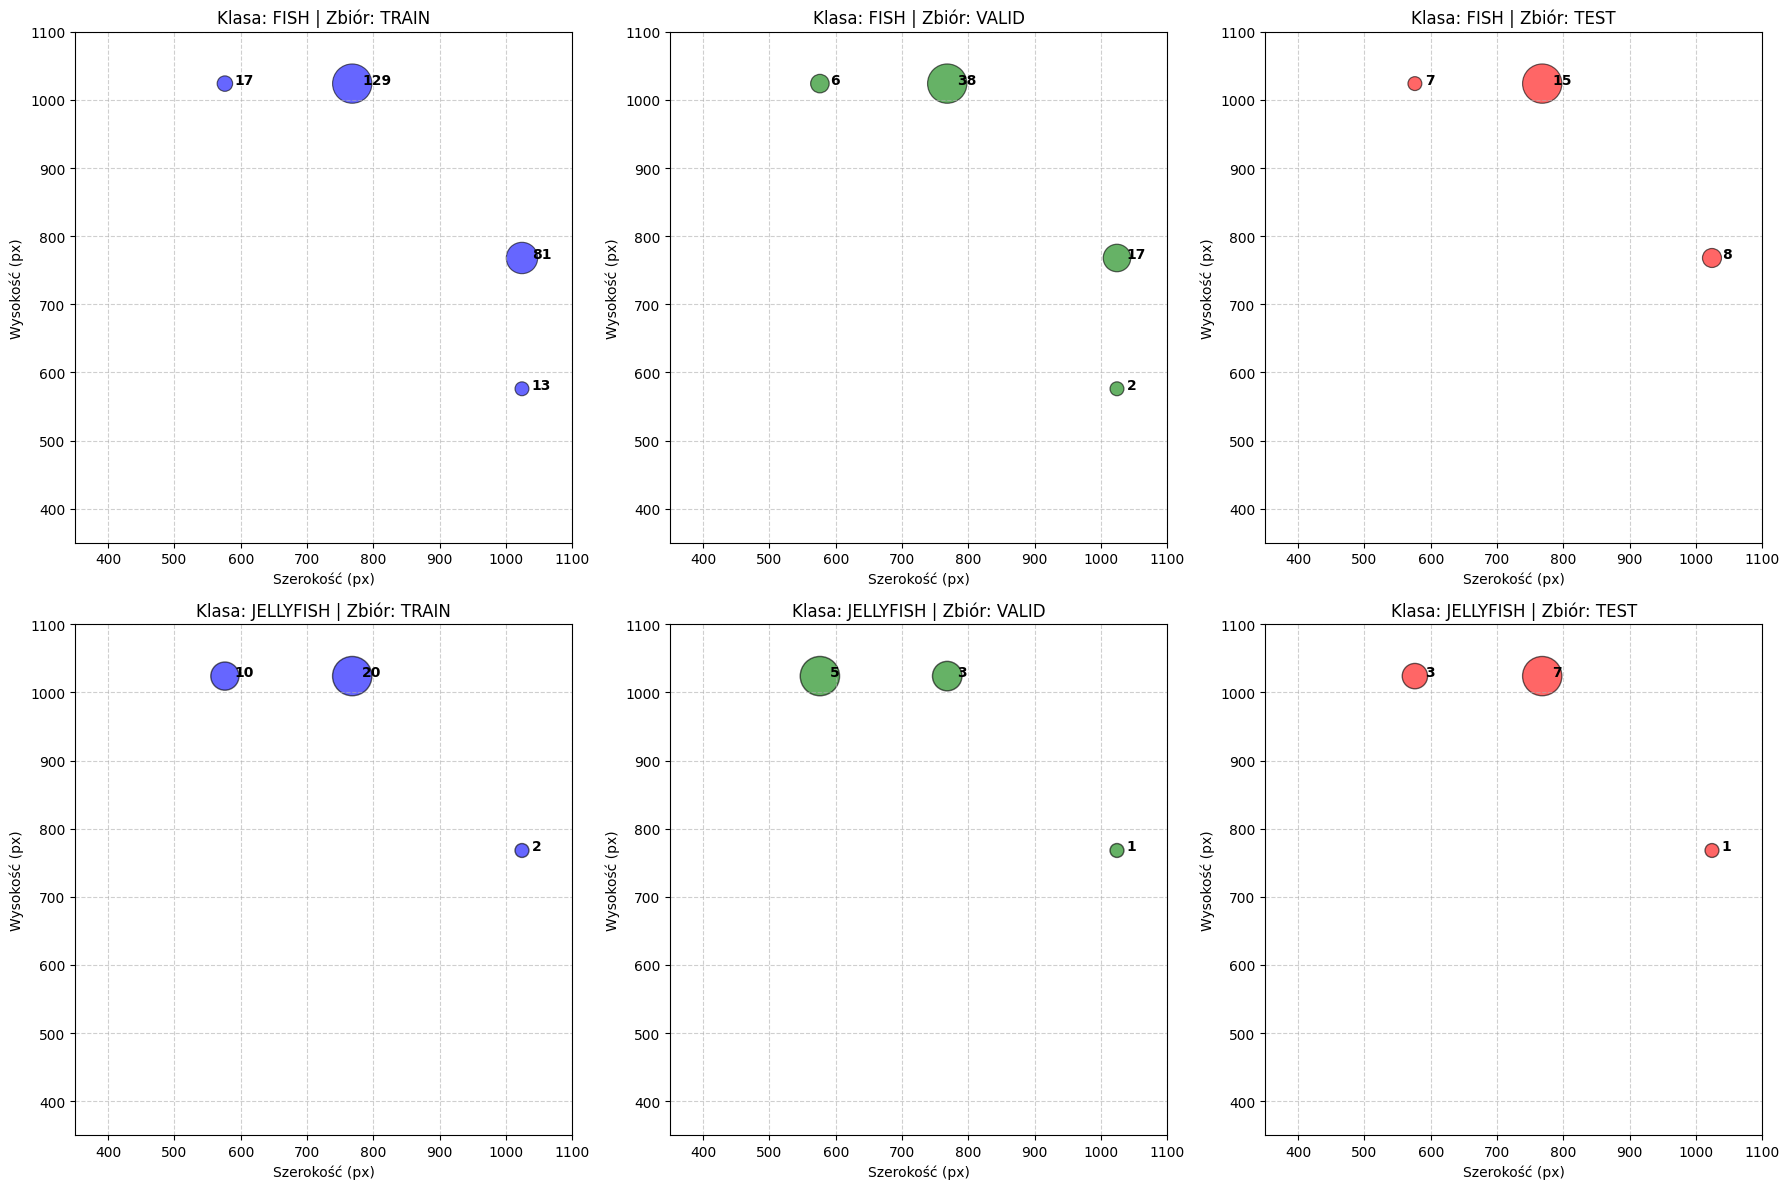

In [53]:
image_sizes = []

for s in sets:
    for img in fishes_data[s]['images']:
        image_sizes.append({
            'Zbiór': s,
            'Szerokość': img['width'],
            'Wysokość': img['height']
        })

df_sizes = pd.DataFrame(image_sizes)

# --- 1. TABELE ZE STATYSTYKAMI (CAŁY ZBIÓR) ---
print("--- STATYSTYKI ROZMIARÓW OBRAZÓW (Cały zbiór) ---")
display(df_sizes[['Szerokość', 'Wysokość']].describe().loc[['min', 'max', 'mean']])

for s in sets:
    print(f"\n--- STATYSTYKI ROZMIARÓW OBRAZÓW (Zbiór: {s.upper()}) ---")
    df_split = df_sizes[df_sizes['Zbiór'] == s]
    display(df_split[['Szerokość', 'Wysokość']].describe().loc[['min', 'max', 'mean']])

# --- 2. PRZYGOTOWANIE DANYCH DO WYKRESÓW Z LICZNOŚCIĄ ---
# Grupowanie, aby zliczyć ile jest zdjęć o danej szerokości i wysokości
df_counts_all = df_sizes.groupby(['Szerokość', 'Wysokość']).size().reset_index(name='Liczba')
df_counts_split = df_sizes.groupby(['Zbiór', 'Szerokość', 'Wysokość']).size().reset_index(name='Liczba')

# --- 3. WYKRES DLA CAŁEGO ZBIORU ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_counts_all, x='Szerokość', y='Wysokość', size='Liczba', sizes=(100, 1000), alpha=0.6, color='teal', edgecolor='black')
plt.title('Rozmiary obrazów (Cały zbiór) - Wielkość koła oznacza liczbę zdjęć')
plt.xlabel('Szerokość (piksele)')
plt.ylabel('Wysokość (piksele)')
plt.grid(True, linestyle='--', alpha=0.6)

# Dodawanie tekstowych etykiet z liczbą zdjęć obok punktów
for i in range(df_counts_all.shape[0]):
    plt.text(df_counts_all['Szerokość'].iloc[i] + 15, df_counts_all['Wysokość'].iloc[i], 
             str(df_counts_all['Liczba'].iloc[i]), color='black', weight='bold', fontsize=10)
plt.show()

# --- 4. WYKRESY DLA POSZCZEGÓLNYCH ZBIORÓW ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = {'train': 'blue', 'valid': 'green', 'test': 'red'}

for i, s in enumerate(sets):
    df_subset = df_counts_split[df_counts_split['Zbiór'] == s].reset_index(drop=True)
    sns.scatterplot(ax=axes[i], data=df_subset, x='Szerokość', y='Wysokość', size='Liczba', sizes=(50, 600), 
                    alpha=0.6, color=colors[s], edgecolor='black', legend=False)
    axes[i].set_title(f'Rozmiary obrazów (Zbiór: {s.upper()})')
    axes[i].set_xlabel('Szerokość (px)')
    axes[i].set_ylabel('Wysokość (px)')
    axes[i].grid(True, linestyle='--', alpha=0.6)
    
    # Dodawanie etykiet tekstowych
    for j in range(df_subset.shape[0]):
        axes[i].text(df_subset['Szerokość'].iloc[j] + 15, df_subset['Wysokość'].iloc[j], 
                     str(df_subset['Liczba'].iloc[j]), color='black', weight='bold', fontsize=10)

plt.tight_layout()
plt.show()


# =====================================================================
# --- 5. DODATEK: WYKRESY TYLKO DLA WYBRANYCH KLAS (FISH, JELLYFISH) ---
# =====================================================================

print("\n--- ANALIZA ROZMIARÓW OBRAZÓW TYLKO DLA WYBRANYCH KLAS ---")

class_image_sizes = []

for s in sets:
    images = fishes_data[s]['images']
    annotations = fishes_data[s]['annotations']
    
    # Tworzymy słownik dla szybkiego dostępu do wymiarów obrazu po jego ID
    img_dict = {img['id']: {'width': img['width'], 'height': img['height']} for img in images}
    
    for target_class in target_classes:  # Zmienna target_classes pochodzi z Komórki 2
        if target_class not in target_cat_ids:
            continue
            
        class_id = target_cat_ids[target_class]
        
        # Znajdź unikalne ID obrazów, które mają adnotację tej klasy
        img_ids_with_class = set([ann['image_id'] for ann in annotations if ann['category_id'] == class_id])
        
        for img_id in img_ids_with_class:
            class_image_sizes.append({
                'Klasa': target_class,
                'Zbiór': s,
                'Szerokość': img_dict[img_id]['width'],
                'Wysokość': img_dict[img_id]['height']
            })

df_class_sizes = pd.DataFrame(class_image_sizes)

if df_class_sizes.empty:
    print("Brak danych do wygenerowania wykresów dla podanych klas.")
else:
    # Przygotowanie danych do wykresów bąbelkowych dla poszczególnych klas
    df_counts_class = df_class_sizes.groupby(['Klasa', 'Zbiór', 'Szerokość', 'Wysokość']).size().reset_index(name='Liczba')
    
    # Rysowanie wykresów (Siatka 2x3: wiersze to klasy, kolumny to zbiory)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    for row_idx, target_class in enumerate(target_classes):
        for col_idx, s in enumerate(sets):
            ax = axes[row_idx, col_idx]
            
            df_subset = df_counts_class[(df_counts_class['Klasa'] == target_class) & (df_counts_class['Zbiór'] == s)].reset_index(drop=True)
            
            if not df_subset.empty:
                sns.scatterplot(ax=ax, data=df_subset, x='Szerokość', y='Wysokość', size='Liczba', 
                                sizes=(100, 800), alpha=0.6, color=colors[s], edgecolor='black', legend=False)
                
                # Dodawanie etykiet tekstowych
                for i in range(df_subset.shape[0]):
                    ax.text(df_subset['Szerokość'].iloc[i] + 15, df_subset['Wysokość'].iloc[i], 
                            str(df_subset['Liczba'].iloc[i]), color='black', weight='bold', fontsize=10)
            
            ax.set_title(f"Klasa: {target_class.upper()} | Zbiór: {s.upper()}")
            ax.set_xlabel('Szerokość (px)')
            ax.set_ylabel('Wysokość (px)')
            ax.grid(True, linestyle='--', alpha=0.6)
            
            # Ujednolicenie osi, żeby łatwiej było porównywać wzrokowo (dopasowane do Twoich obrazów max 1024)
            ax.set_xlim(350, 1100)
            ax.set_ylim(350, 1100)

    plt.tight_layout()
    plt.show()

# Detekcja - Balans klas i statystyki BBoxów - Balans klas, Liczba masek/boxów na klasę, Średnia powierzchnia bounding boxów, Średnia liczba bboxów na klasę

--- STATYSTYKI DETEKCJI (CAŁOŚĆ) ---
Średnia powierzchnia bounding boxa ogółem: 20202.27 pikseli kwadratowych
Średnia liczba bboxów przypadająca na jedną klasę: 237.59

--- ŚREDNIA POWIERZCHNIA BBOXA W POSZCZEGÓLNYCH ZBIORACH ---
Zbiór TRAIN: 20629.51 pikseli kwadratowych
Zbiór VALID: 20341.75 pikseli kwadratowych
Zbiór TEST: 18031.00 pikseli kwadratowych




/tmp/ipykernel_137328/985012103.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=boxes_per_class.values, y=boxes_per_class.index, palette="viridis")


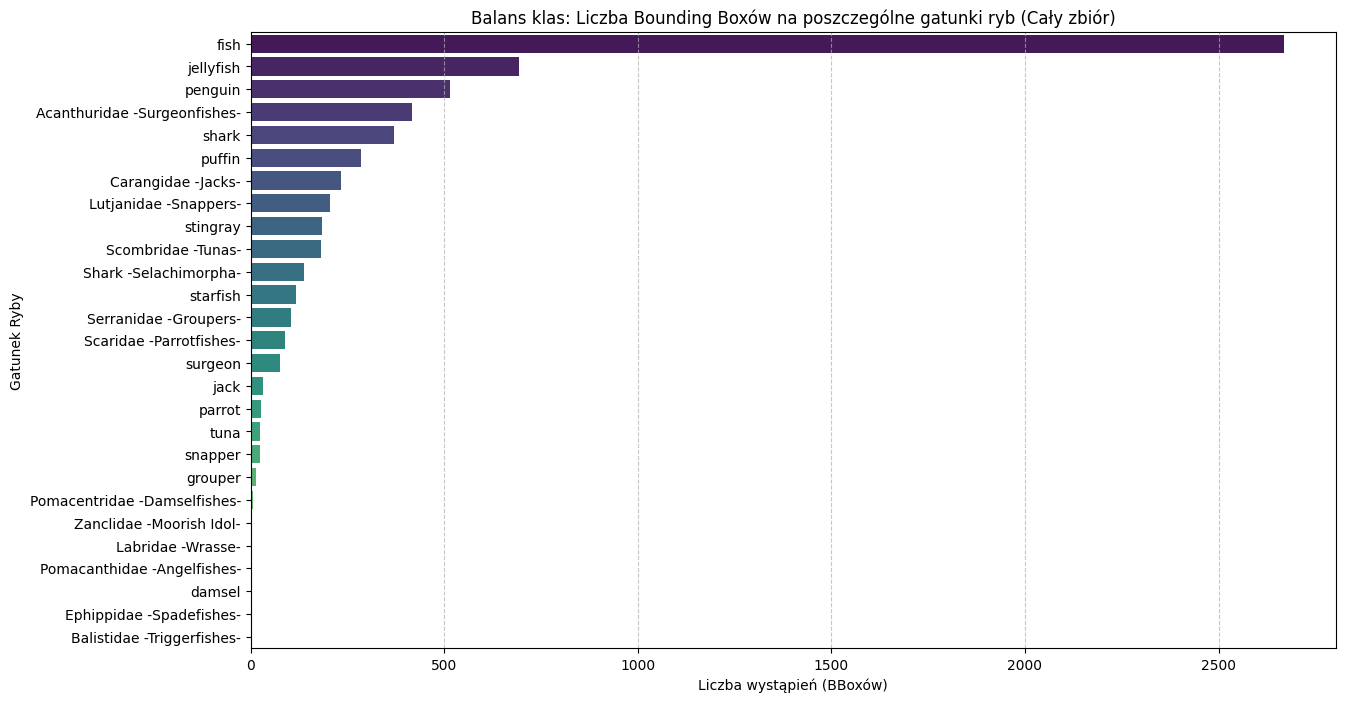

Tabela podsumowująca liczbę bboxów na klasę:


,Liczba BBoxów
Nazwa_Gatunku,
fish,2669
jellyfish,694
penguin,516
Acanthuridae -Surgeonfishes-,416
shark,371
puffin,284
Carangidae -Jacks-,234
Lutjanidae -Snappers-,206
stingray,184


In [54]:
all_annotations = []
for s in sets:
    for ann in fishes_data[s]['annotations']:
        ann_copy = ann.copy()
        ann_copy['Zbiór'] = s  # Dodajemy informację o zbiorze do każdego bboxa
        all_annotations.append(ann_copy)

df_bboxes = pd.DataFrame(all_annotations)
# Dodanie nazwy klasy na podstawie category_id
df_bboxes['Nazwa_Gatunku'] = df_bboxes['category_id'].map(fish_categories)

# --- 1. OBLICZENIA DLA CAŁEGO ZBIORU ---
average_bbox_area = df_bboxes['area'].mean()
boxes_per_class = df_bboxes['Nazwa_Gatunku'].value_counts()
average_boxes_per_class = boxes_per_class.mean()

print("--- STATYSTYKI DETEKCJI (CAŁOŚĆ) ---")
print(f"Średnia powierzchnia bounding boxa ogółem: {average_bbox_area:.2f} pikseli kwadratowych")
print(f"Średnia liczba bboxów przypadająca na jedną klasę: {average_boxes_per_class:.2f}\n")

# --- 2. ŚREDNIA POWIERZCHNIA BBOXA (Z PODZIAŁEM NA ZBIORY) ---
print("--- ŚREDNIA POWIERZCHNIA BBOXA W POSZCZEGÓLNYCH ZBIORACH ---")
for s in sets:
    split_area = df_bboxes[df_bboxes['Zbiór'] == s]['area'].mean()
    print(f"Zbiór {s.upper()}: {split_area:.2f} pikseli kwadratowych")
print("\n")

# --- 3. WYKRES BALANSU KLAS ---
plt.figure(figsize=(14, 8))
sns.barplot(x=boxes_per_class.values, y=boxes_per_class.index, palette="viridis")
plt.title('Balans klas: Liczba Bounding Boxów na poszczególne gatunki ryb (Cały zbiór)')
plt.xlabel('Liczba wystąpień (BBoxów)')
plt.ylabel('Gatunek Ryby')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Tabela podsumowująca liczbę bboxów na klasę:")
display(pd.DataFrame(boxes_per_class).rename(columns={'count': 'Liczba BBoxów'}))

# Wizualizacja danych z etykietami - Wyświetl przykładowe obrazy wraz z bounding boxami

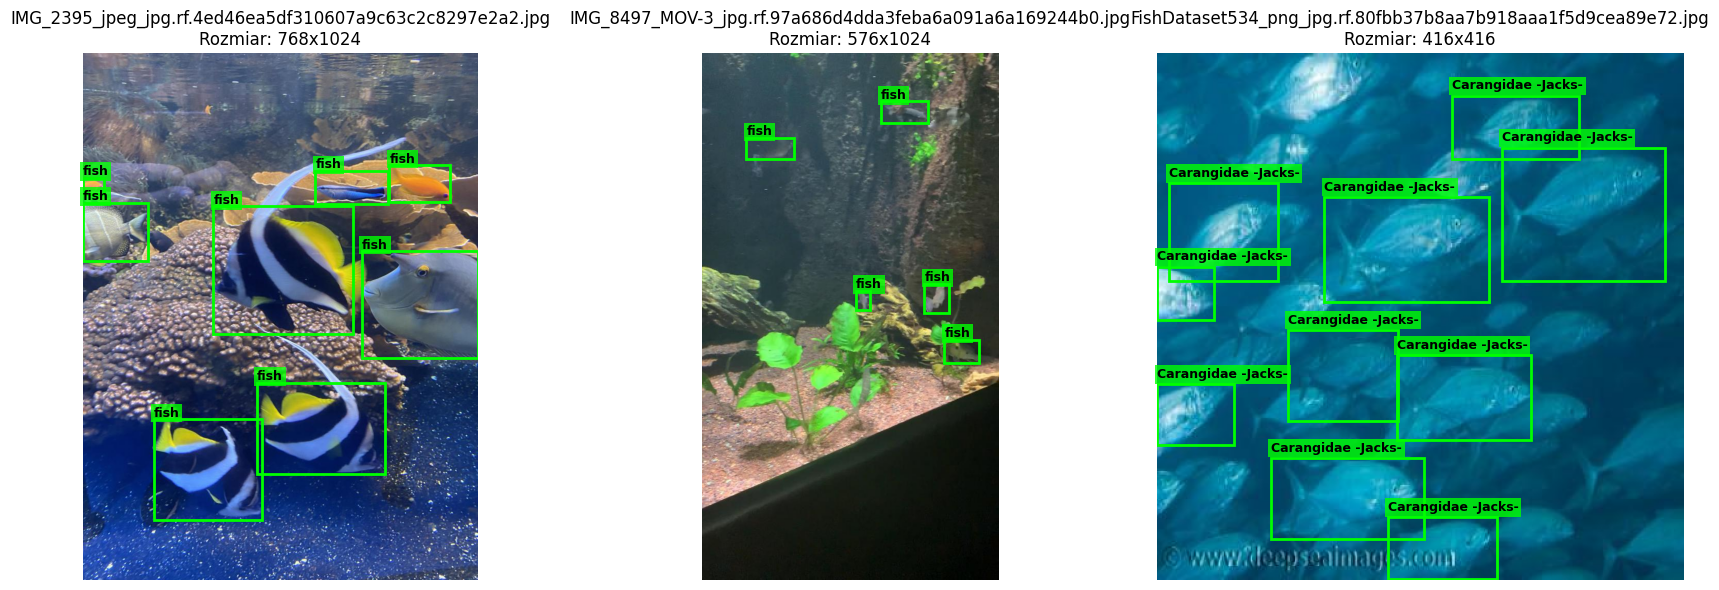

In [55]:
def imshow_fishes(set_name='train', num_images=3):
    data = fishes_data[set_name]
    images_list = data['images']
    anns_list = data['annotations']
    
    # Wybieramy losowe obrazy
    sample_imgs = random.sample(images_list, num_images)

    fig, axes = plt.subplots(1, num_images, figsize=(18, 6))
    if num_images == 1: axes = [axes]

    for ax, img_info in zip(axes, sample_imgs):
        img_path = data_dir / set_name / img_info['file_name']
        
        # Wczytanie i konwersja kolorów
        image = cv2.imread(str(img_path))
        if image is None:
            ax.set_title("Błąd wczytywania")
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ax.imshow(image)
        ax.axis('off')
        
        # Wymiary rzeczywiste wrzucone w tytuł dla potwierdzenia
        ax.set_title(f"{img_info['file_name']}\nRozmiar: {img_info['width']}x{img_info['height']}")

        # Filtrowanie bboxów dla tego konkretnego zdjęcia
        fish_bboxes = [ann for ann in anns_list if ann['image_id'] == img_info['id']]

        # Rysowanie Bounding Boxów
        for ann in fish_bboxes:
            x, y, w, h = ann['bbox']
            # Rysujemy ramkę
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='#00FF00', facecolor='none')
            ax.add_patch(rect)
            
            # Podpis gatunku
            species_name = fish_categories[ann['category_id']]
            ax.text(x, max(0, y - 5), species_name, color='black', fontsize=9, weight='bold',
                    bbox=dict(facecolor='#00FF00', alpha=0.8, edgecolor='none', pad=2))

    plt.tight_layout()
    plt.show()

# Uruchomienie funkcji - wyświetlamy 3 losowe ryby ze zbioru testowego
imshow_fishes(set_name='test', num_images=3)

# import + transformacje (augmentacja)
Wielkość zdjęcia 416x416
Wykorzystanie Albumentations - Letterboxing (LongestMaxSize + PadIfNeeded) -> ryby nie będą jak w tych memach spłaszczone

In [56]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import numpy as np

# Zdefiniowanie stałych
BATCH_SIZE = 8 # Możesz zmienić na 16, jeśli Twoja karta graficzna ma dużo pamięci
IMG_SIZE = 416
TARGET_CLASSES = ['fish', 'jellyfish']

# Transformacje dla zbioru TRENINGOWEGO (z augmentacjami)
train_transform = A.Compose([
    # Skalowanie z zachowaniem proporcji
    A.LongestMaxSize(max_size=IMG_SIZE),
    # Dodanie czarnych pasków, by obraz był idealnym kwadratem 416x416
    A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=[0, 0, 0]),
    # Augmentacje
    A.HorizontalFlip(p=0.5), # 50% szans na odbicie lustrzane
    A.RandomBrightnessContrast(p=0.2), # Delikatna zmiana jasności
    # Normalizacja standardowa dla PyTorch i konwersja na Tensor
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), 
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))

# Transformacje dla zbioru WALIDACYJNEGO I TESTOWEGO (BEZ augmentacji, tylko zmiana rozmiaru)
val_test_transform = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=[0, 0, 0]),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))

print("Zdefiniowano transformacje i augmentacje.")

Zdefiniowano transformacje i augmentacje.


/tmp/ipykernel_137328/431992809.py:18: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=[0, 0, 0]),
/tmp/ipykernel_137328/431992809.py:30: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=[0, 0, 0]),


# Dodanie klasy MyDataset i collate_fn
Zbiór danych zwraca parę. Obraz jako tensor oraz target (słownik z ramkami i etykietami)
Implementacja 3 metod:
__init__ (inicjalizacja ścieżek i transformacji)
__len__ (liczba próbek)
__getitem__ (pobranie pojedynczej próbki po indeksie)

In [57]:
class MyDataset(Dataset):
    def __init__(self, data_dir, set_name, json_data, target_classes, transform=None):
        self.data_dir = data_dir / set_name
        self.transform = transform
        self.json_data = json_data
        
        # Słownik zamieniający nazwy klas na ID: np. {'fish': 1, 'jellyfish': 2}
        self.class_name_to_id = {name: idx + 1 for idx, name in enumerate(target_classes)}
        
        # Szukamy oryginalnych ID z pliku JSON dla interesujących nas klas
        valid_cat_ids = [cat['id'] for cat in json_data['categories'] if cat['name'].lower() in target_classes]
        
        self.images = []
        self.annotations = []
        img_dict = {img['id']: img for img in json_data['images']}
        
        # Zgrupowanie adnotacji po obrazku i odrzucenie tych bez naszych ryb
        from collections import defaultdict
        ann_by_img = defaultdict(list)
        for ann in json_data['annotations']:
            if ann['category_id'] in valid_cat_ids:
                ann_by_img[ann['image_id']].append(ann)
                
        for img_id, anns in ann_by_img.items():
            self.images.append(img_dict[img_id])
            self.annotations.append(anns)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = self.data_dir / img_info['file_name']
        
        # 1. Wczytanie obrazu
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # 2. Przetworzenie Bounding Boxów (Z formatu COCO na Pascal VOC)
        bboxes = []
        labels = []
        for ann in self.annotations[idx]:
            x_min, y_min, w, h = ann['bbox']
            x_max = x_min + w
            y_max = y_min + h
            
            # Zabezpieczenie przed błędami w danych (ramki poza ekranem)
            x_min, y_min = max(0, x_min), max(0, y_min)
            x_max, y_max = min(img_info['width'], x_max), min(img_info['height'], y_max)
            
            if x_max > x_min and y_max > y_min:
                bboxes.append([x_min, y_min, x_max, y_max])
                # Znajdź nazwę oryginalną i przypisz nasze nowe ID (1 lub 2)
                orig_cat_id = ann['category_id']
                orig_cat_name = next(c['name'] for c in self.json_data['categories'] if c['id'] == orig_cat_id).lower()
                labels.append(self.class_name_to_id[orig_cat_name])

        target = {}
        # 3. Aplikowanie transformacji z Albumentations
        if self.transform:
            transformed = self.transform(image=image, bboxes=bboxes, class_labels=labels)
            image = transformed['image']
            bboxes = transformed['bboxes']
            labels = transformed['class_labels']

        # 4. Konwersja do formatu, którego oczekuje PyTorch
        target['boxes'] = torch.as_tensor(bboxes, dtype=torch.float32)
        target['labels'] = torch.as_tensor(labels, dtype=torch.int64)
        target['image_id'] = torch.tensor([img_info['id']])
        
        # Jeśli augmentacja usunęła wszystkie ramki (bardzo rzadkie przy letterboxingu)
        if len(bboxes) == 0:
            target['boxes'] = torch.zeros((0, 4), dtype=torch.float32)
            target['labels'] = torch.zeros((0,), dtype=torch.int64)

        return image, target

# Funkcja pomocnicza: sieci Object Detection zwracają różną ilość ramek dla różnych zdjęć, 
# więc domyślny loader by zwariował (wymagałby tej samej liczby). Ta funkcja temu zapobiega.
def custom_collate_fn(batch):
    return tuple(zip(*batch))

print("Klasa MyDataset i funkcja collate_fn gotowe.")

Klasa MyDataset i funkcja collate_fn gotowe.


# Tworzenie Dataloaderów
Inicjacja naszych zbiorów i pakowanie w obiekty DataLoader

In [58]:
# Inicjalizacja zbiorów danych
train_dataset = MyDataset(data_dir, 'train', fishes_data['train'], TARGET_CLASSES, transform=train_transform)
valid_dataset = MyDataset(data_dir, 'valid', fishes_data['valid'], TARGET_CLASSES, transform=val_test_transform)
test_dataset = MyDataset(data_dir, 'test', fishes_data['test'], TARGET_CLASSES, transform=val_test_transform)

# Tworzenie Dataloaderów
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=custom_collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=custom_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=custom_collate_fn)

print(f"Ilość paczek (batchy) treningowych: {len(train_loader)}")
print(f"Ilość paczek walidacyjnych: {len(valid_loader)}")
print(f"Ilość paczek testowych: {len(test_loader)}")

Ilość paczek (batchy) treningowych: 34
Ilość paczek walidacyjnych: 9
Ilość paczek testowych: 6


# Pokazanie obrazów z i bez augmentacji -> imshow

/tmp/ipykernel_137328/2257896421.py:41: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=[0, 0, 0]),


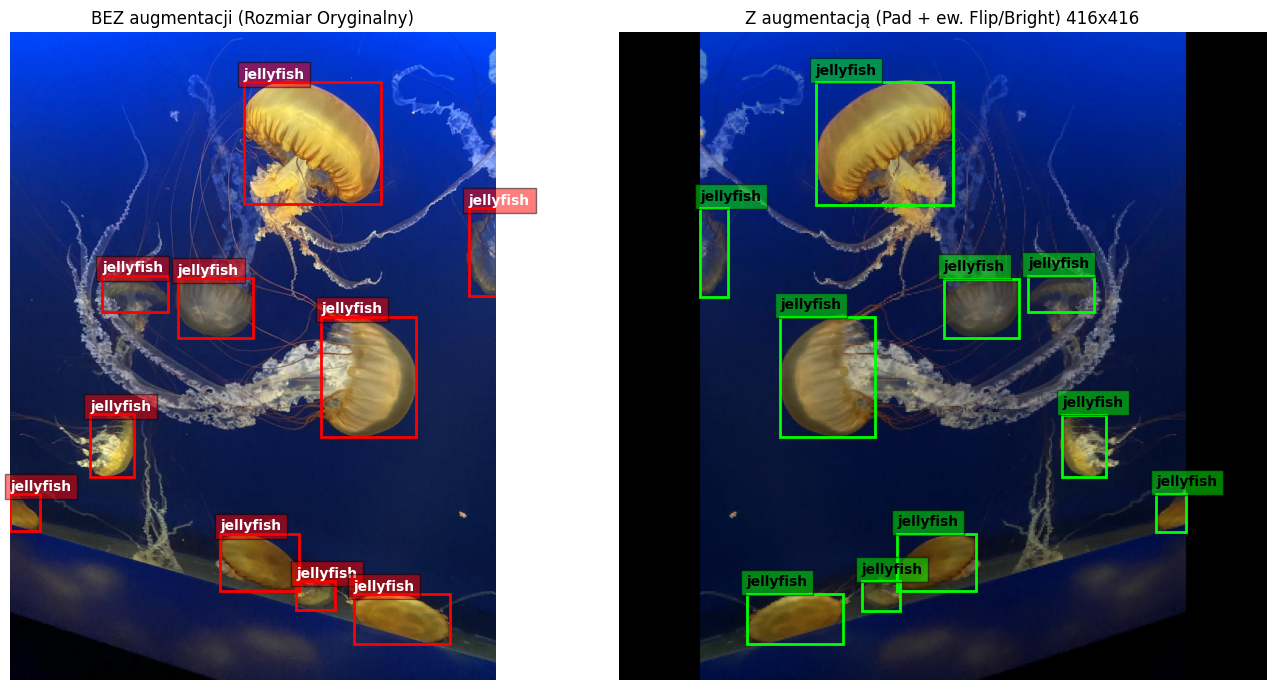

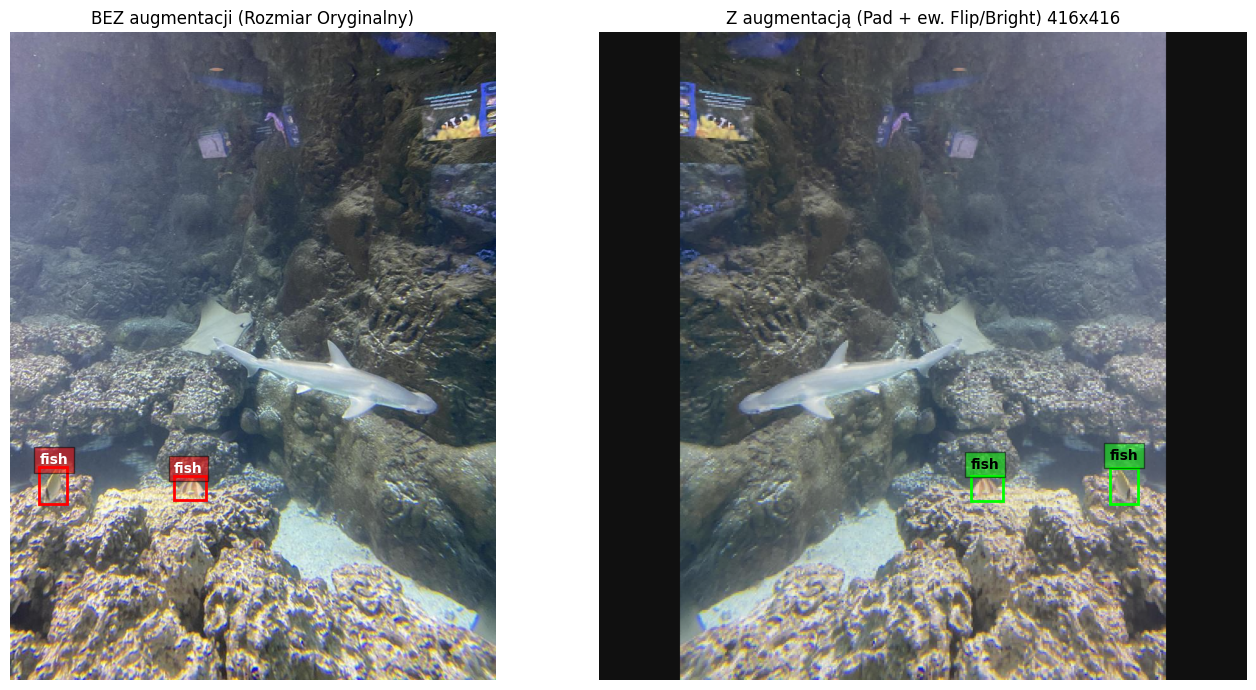

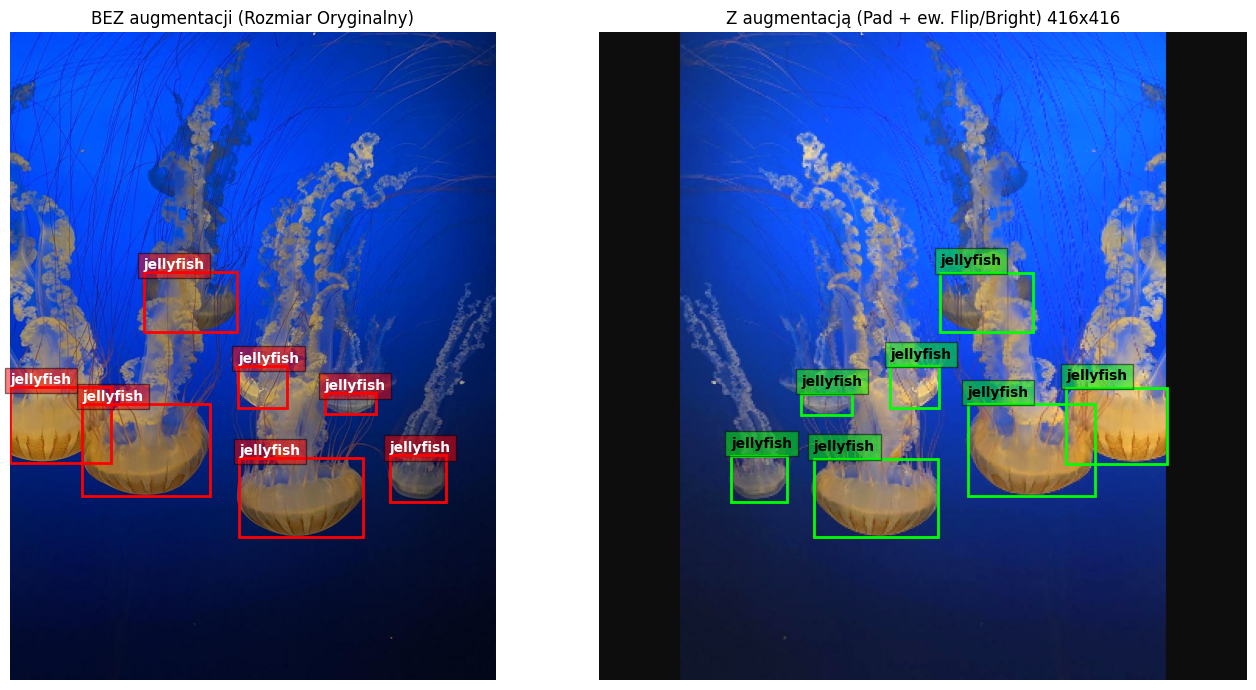

In [59]:
def imshow_comparison(dataset_no_aug, dataset_aug, idx=0):
    """
    Funkcja pobiera obrazek i bounding boxy, a następnie rysuje wersję przed i po augmentacji.
    """
    # Zastrzegamy odwrotne mapowanie ID -> Nazwa
    id_to_class = {v: k for k, v in dataset_no_aug.class_name_to_id.items()}
    
    # Wczytanie z obu zbiorów
    img_no_aug, target_no_aug = dataset_no_aug[idx]
    img_aug, target_aug = dataset_aug[idx]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    
    # 1. Obraz BEZ augmentacji
    axes[0].imshow(img_no_aug)
    axes[0].set_title('BEZ augmentacji (Rozmiar Oryginalny)')
    axes[0].axis('off')
    for box, label in zip(target_no_aug['boxes'], target_no_aug['labels']):
        x_min, y_min, x_max, y_max = box
        rect = patches.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min, linewidth=2, edgecolor='red', facecolor='none')
        axes[0].add_patch(rect)
        axes[0].text(x_min, max(0, y_min-5), id_to_class[label.item()], color='white', weight='bold', bbox=dict(facecolor='red', alpha=0.5))

    # 2. Obraz Z augmentacją
    axes[1].imshow(img_aug)
    axes[1].set_title(f'Z augmentacją (Pad + ew. Flip/Bright) {IMG_SIZE}x{IMG_SIZE}')
    axes[1].axis('off')
    for box, label in zip(target_aug['boxes'], target_aug['labels']):
        x_min, y_min, x_max, y_max = box
        rect = patches.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min, linewidth=2, edgecolor='#00FF00', facecolor='none')
        axes[1].add_patch(rect)
        axes[1].text(x_min, max(0, y_min-5), id_to_class[label.item()], color='black', weight='bold', bbox=dict(facecolor='#00FF00', alpha=0.5))

    plt.tight_layout()
    plt.show()

# Definiujemy transformację WIZUALNĄ (wymuszamy 100% szans na nałożenie, żeby to zaprezentować, 
# i wyłączamy Normalize, żeby kolory nie zwariowały na wykresie)
visual_transform = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=[0, 0, 0]),
    A.HorizontalFlip(p=1.0), # Celowo p=1.0 by zawsze odbił lustrzanie do pokazu
    A.RandomBrightnessContrast(p=1.0) # Zawsze lekko zmieni jasność
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))

# Tworzymy 2 zbiory wizualne (tylko na potrzeby pokazania tego prowadzącemu)
vis_dataset_no_aug = MyDataset(data_dir, 'train', fishes_data['train'], TARGET_CLASSES, transform=None)
vis_dataset_aug = MyDataset(data_dir, 'train', fishes_data['train'], TARGET_CLASSES, transform=visual_transform)

# Wyświetlamy 3 przykładowe zestawienia (np. indeksy 0, 5, 10 ze zbioru)
for i in [0, 5, 10]:
    imshow_comparison(vis_dataset_no_aug, vis_dataset_aug, idx=i)

Po padingu widzimy czarne ramki na zdjęciach - letterboxing, co oznacza, że zostały dobrze skompresowane do idealnego kwadratu 416x416 bez scalania ryb. Bounding boxy "wędrują" po nałożeniu efektu lustra - dzięki temu że użyliśmy Albumentations

# 4. Definicja modelu sieci neuronowej

In [60]:
import torch
import torch.nn as nn
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# 1. Definicja klasy modelu (zgodnie z templatką)
class Net(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Wczytujemy przeuczony model Faster R-CNN z backbone'em ResNet50
        # Używamy wag domyślnych (DEFAULT), czyli modelu trenowanego na gigantycznym zbiorze COCO
        self.model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')

        # Pobieramy liczbę wejść do ostatniej warstwy klasyfikującej
        in_features = self.model.roi_heads.box_predictor.cls_score.in_features

        # Podmieniamy domyślną głowę modelu na nową, która zwróci naszą liczbę klas
        self.model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    def forward(self, images, targets=None):
        # W trybie treningu (gdy targets nie są None), model zwróci słownik z obliczonymi stratami (loss)
        # W trybie ewaluacji (testu), model zwróci predykcje (bboxy, klasy, pewność)
        return self.model(images, targets)

# 2. Utworzenie obiektu 'net'
# PAMIĘTAJ: Mamy 3 klasy! W detekcji w PyTorch klasa '0' jest zawsze zarezerwowana dla tła (background).
# Nasze klasy to: 0 - Tło, 1 - Fish, 2 - Jellyfish.
NUM_CLASSES = 3 
net = Net(NUM_CLASSES)

# Przeniesienie modelu na kartę graficzną (niezbędne do szybkiego treningu)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
net.to(device)
print(f"Model załadowany i przeniesiony na urządzenie: {device}")

# 3. Zdefiniowanie Optymalizatora
# Zbieramy parametry modelu, które będą aktualizowane podczas treningu
params = [p for p in net.parameters() if p.requires_grad]

# Używamy optymalizatora SGD (Stochastic Gradient Descent) - to standard przy Faster R-CNN
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

# 4. Zdefiniowanie funkcji celu (Criterion)
# Wyjaśnienie dla prowadzącego (możesz to dodać w komentarzu w kodzie):
# Modele detekcyjne z torchvision wewnętrznie obliczają 'loss' z kilku komponentów 
# (np. błędu ramki i błędu klasyfikacji) podczas wywołania funkcji forward() w trybie treningu.
criterion = "Funkcja celu jest obliczana wewnętrznie przez model Faster R-CNN."

print("Optymalizator gotowy. Model jest przygotowany do treningu!")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /home/mateu/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100.0%


Model załadowany i przeniesiony na urządzenie: cpu
Optymalizator gotowy. Model jest przygotowany do treningu!


/home/mateu/msi_projekt/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12050). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
